Prepare the Dataset

In [ ]:
"""
Prepare the Shakespeare dataset for character-level language modeling.
So instead of encoding with GPT-2 BPE tokens, we just map characters to ints.
Will save train.bin, val.bin containing the ids, and meta.pkl containing the
encoder and decoder and some other related info.
"""
import os
import pickle
import requests
import numpy as np



def prepare_dataset(
    dataset_name,
    default_dataset=True,   # "shakespeare" or "custom"
    use_char=True,        # "char" or "bpe"
    custom_input_file=None,
    train_split=0.9,
    download_if_missing=True,
    shakespeare_url="https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
    bpe_vocab_size=2000,
    bpe_min_frequency=2,
):
    # download the tiny shakespeare dataset
    directory_path = os.path.join(os.path.abspath(''),"data", dataset_name)
    input_file_path = os.path.join(directory_path, 'input.txt')

    print(directory_path)

    if default_dataset:
        if not os.path.exists(directory_path):
            os.makedirs(directory_path)
        if not os.path.exists(input_file_path):
            data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
            with open(input_file_path, 'w') as f:
                f.write(requests.get(data_url).text)
    else:
        if custom_input_file is None:
            raise ValueError("For dataset_mode='custom', you must provide custom_input_file")

        if not os.path.exists(custom_input_file):
            raise FileNotFoundError(f"Custom input file not found: {custom_input_file}")

        with open(custom_input_file, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        with open(input_file_path, "w", encoding="utf-8") as f:
            f.write(text)

    with open(input_file_path, 'r', encoding='utf-8') as f:
        data = f.read()
    print(f"length of dataset in characters: {len(data):,}")
    if use_char:
        # get all the unique characters that occur in this text
        chars = sorted(list(set(data)))
        vocab_size = len(chars)
        print("all the unique characters:", ''.join(chars))
        print(f"vocab size: {vocab_size:,}")

        # create a mapping from characters to integers
        stoi = { ch:i for i,ch in enumerate(chars) }
        itos = { i:ch for i,ch in enumerate(chars) }
        def encode(s):
            return [stoi[c] for c in s] # encoder: take a string, output a list of integers
        def decode(l):
            return ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

        # create the train and test splits
        n = len(data)
        train_data = data[:int(n*0.9)]
        val_data = data[int(n*0.9):]

        # encode both to integers
        train_ids = encode(train_data)
        val_ids = encode(val_data)
        print(f"train has {len(train_ids):,} tokens")
        print(f"val has {len(val_ids):,} tokens")

        # export to bin files
        train_ids = np.array(train_ids, dtype=np.uint16)
        val_ids = np.array(val_ids, dtype=np.uint16)
        train_ids.tofile(os.path.join(directory_path, 'train.bin'))
        val_ids.tofile(os.path.join(directory_path, 'val.bin'))

        # save the meta information as well, to help us encode/decode later
        meta = {
            'vocab_size': vocab_size,
            'itos': itos,
            'stoi': stoi,
        }
        with open(os.path.join(directory_path, 'meta.pkl'), 'wb') as f:
            pickle.dump(meta, f)

        # length of dataset in characters:  1115394
        # all the unique characters:
        #  !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
        # vocab size: 65
        # train has 1003854 tokens
        # val has 111540 tokens
    else:
        try:
            from tokenizers import Tokenizer
            from tokenizers.models import BPE
            from tokenizers.trainers import BpeTrainer
            from tokenizers.pre_tokenizers import ByteLevel
            from tokenizers.decoders import ByteLevel as ByteLevelDecoder
        except ImportError:
            raise ImportError(
                "BPE mode requires the 'tokenizers' package.\n"
                "Install it in the notebook with:\n"
                "!pip install tokenizers"
            )

        tokenizer_path = os.path.join(directory_path, "tokenizer.json")

        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()

        trainer = BpeTrainer(
            vocab_size=bpe_vocab_size,
            min_frequency=bpe_min_frequency,
            special_tokens=["[UNK]"]
        )

        tokenizer.train([input_file_path], trainer)
        tokenizer.save(tokenizer_path)

        ids = tokenizer.encode(data).ids
        vocab_size = tokenizer.get_vocab_size()

        print(f"BPE vocab size: {vocab_size:,}")
        print(f"Total BPE tokens: {len(ids):,}")

        n = len(ids)
        train_ids = np.array(ids[:int(n * train_split)], dtype=np.uint16)
        val_ids = np.array(ids[int(n * train_split):], dtype=np.uint16)

        print(f"Train has {len(train_ids):,} tokens")
        print(f"Val has {len(val_ids):,} tokens")

        train_ids.tofile(os.path.join(directory_path, "train.bin"))
        val_ids.tofile(os.path.join(directory_path, "val.bin"))

        meta = {
            "vocab_size": vocab_size,
            "tokenizer_type": "bpe",
            "tokenizer_path": "tokenizer.json",
            "dataset_mode": "bpe",
            "bpe_vocab_size": bpe_vocab_size,
            "bpe_min_frequency": bpe_min_frequency,
        }

        with open(os.path.join(directory_path, "meta.pkl"), "wb") as f:
            pickle.dump(meta, f)

        print("Saved BPE dataset files.")

    print("\nDone.")
    return {
        "dataset_dir": directory_path,
        "input_file_path": input_file_path,
        "tokenizer_mode": use_char,
        "dataset_mode": default_dataset,
    }


Prepare Char tokens Dataset

In [2]:
prepare_dataset(
    dataset_name="shakespeare_char",
    default_dataset=True,
    use_char=True,
)

c:\Users\lunat\Documents\GitHub\foundations_NLP\final_assignment\data\shakespeare_char
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens

Done.


{'dataset_dir': 'c:\\Users\\lunat\\Documents\\GitHub\\foundations_NLP\\final_assignment\\data\\shakespeare_char',
 'input_file_path': 'c:\\Users\\lunat\\Documents\\GitHub\\foundations_NLP\\final_assignment\\data\\shakespeare_char\\input.txt',
 'tokenizer_mode': True,
 'dataset_mode': True}

Baseline Configuration

Prepare BPE Token Dataset

In [3]:
prepare_dataset(
    dataset_name="shakespeare_bpe",
    default_dataset=True,
    use_char=False,
    bpe_vocab_size=2000
)

c:\Users\lunat\Documents\GitHub\foundations_NLP\final_assignment\data\shakespeare_bpe
length of dataset in characters: 1,115,394
BPE vocab size: 2,000
Total BPE tokens: 412,174
Train has 370,956 tokens
Val has 41,218 tokens
Saved BPE dataset files.

Done.


{'dataset_dir': 'c:\\Users\\lunat\\Documents\\GitHub\\foundations_NLP\\final_assignment\\data\\shakespeare_bpe',
 'input_file_path': 'c:\\Users\\lunat\\Documents\\GitHub\\foundations_NLP\\final_assignment\\data\\shakespeare_bpe\\input.txt',
 'tokenizer_mode': False,
 'dataset_mode': True}

In [4]:
#Baseline configuration
out_dir = 'out-shakespeare-baseline'
eval_interval = 200
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'baseline'
dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2
learning_rate = 1e-3
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100
weight_decay = 1e-1
device = 'cuda' # change to 'cuda' if you have a GPU
compile = False # set True only on Linux with GPU

#for testing
num_samples=3
max_new_tokens=500

In [5]:
"""
Full definition of a GPT Language Model, all of it in this single file.
References:
1) the official GPT-2 TensorFlow implementation released by OpenAI:
https://github.com/openai/gpt-2/blob/master/src/model.py
2) huggingface/transformers PyTorch implementation:
https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py
"""

import math
import inspect
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F

class LayerNorm(nn.Module):
    """ LayerNorm but with an optional bias. PyTorch doesn't support simply bias=False """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            print("WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0")
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # with weight tying when using torch.compile() some warnings get generated:
        # "UserWarning: functional_call was passed multiple values for tied weights.
        # This behavior is deprecated and will be an error in future versions"
        # not 100% sure what this is, so far seems to be harmless. TODO investigate
        self.transformer.wte.weight = self.lm_head.weight # https://paperswithcode.com/method/weight-tying

        # init all weights
        self.apply(self._init_weights)
        # apply special scaled init to the residual projections, per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        """
        Return the number of parameters in the model.
        For non-embedding count (default), the position embeddings get subtracted.
        The token embeddings would too, except due to the parameter sharing these
        params are actually used as weights in the final layer, so we include them.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

    def crop_block_size(self, block_size):
        # model surgery to decrease the block size if necessary
        # e.g. we may load the GPT2 pretrained model checkpoint (block size 1024)
        # but want to use a smaller block size for some smaller, simpler model
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:,:,:block_size,:block_size]

    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        override_args = override_args or {} # default to empty dict
        # only dropout can be overridden see more notes below
        assert all(k == 'dropout' for k in override_args)
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        # we can override the dropout rate, if desired
        if 'dropout' in override_args:
            print(f"overriding dropout rate to {override_args['dropout']}")
            config_args['dropout'] = override_args['dropout']
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        # start with all of the candidate parameters
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # filter out those that do not require grad
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, **extra_args)
        print(f"using fused AdamW: {use_fused}")

        return optimizer

    def estimate_mfu(self, fwdbwd_per_iter, dt):
        """ estimate model flops utilization (MFU) in units of A100 bfloat16 peak FLOPS """
        # first estimate the number of flops we do per iteration.
        # see PaLM paper Appendix B as ref: https://arxiv.org/abs/2204.02311
        N = self.get_num_params()
        cfg = self.config
        L, H, Q, T = cfg.n_layer, cfg.n_head, cfg.n_embd//cfg.n_head, cfg.block_size
        flops_per_token = 6*N + 12*L*H*Q*T
        flops_per_fwdbwd = flops_per_token * T
        flops_per_iter = flops_per_fwdbwd * fwdbwd_per_iter
        # express our flops throughput as ratio of A100 bfloat16 peak flops
        flops_achieved = flops_per_iter * (1.0/dt) # per second
        flops_promised = 312e12 # A100 GPU bfloat16 peak flops is 312 TFLOPS
        mfu = flops_achieved / flops_promised
        return mfu

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Take a conditioning sequence of indices idx (LongTensor of shape (b,t)) and complete
        the sequence max_new_tokens times, feeding the predictions back into the model each time.
        Most likely you'll want to make sure to be in model.eval() mode of operation for this.
        """
        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # forward the model to get the logits for the index in the sequence
            logits, _ = self(idx_cond)
            # pluck the logits at the final step and scale by desired temperature
            logits = logits[:, -1, :] / temperature
            # optionally crop the logits to only the top k options
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            # apply softmax to convert logits to (normalized) probabilities
            probs = F.softmax(logits, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


In [6]:
"""
This training script can be run both on a single gpu in debug mode,
and also in a larger training run with distributed data parallel (ddp).

To run on a single GPU, example:
$ python train.py --batch_size=32 --compile=False

To run with DDP on 4 gpus on 1 node, example:
$ torchrun --standalone --nproc_per_node=4 train.py

To run with DDP on 4 gpus across 2 nodes, example:
- Run on the first (master) node with example IP 123.456.123.456:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=0 --master_addr=123.456.123.456 --master_port=1234 train.py
- Run on the worker node:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=1 --master_addr=123.456.123.456 --master_port=1234 train.py
(If your cluster does not have Infiniband interconnect prepend NCCL_IB_DISABLE=1)
"""

import os
import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

# -----------------------------------------------------------------------------
# default config values designed to train a gpt2 (124M) on OpenWebText
# I/O
eval_only = False # if True, script exits right after the first eval
init_from = 'scratch' # 'scratch' or 'resume' or 'gpt2*'
# model
bias = False # do we use bias inside LayerNorm and Linear layers?
# adamw optimizer
beta1 = 0.9
grad_clip = 1.0 # clip gradients at this value, or disable if == 0.0
# learning rate decay settings
decay_lr = True # whether to decay the learning rate
lr_decay_iters = 600000 # should be ~= max_iters per Chinchilla
# DDP settings
backend = 'nccl' # 'nccl', 'gloo', etc.
# system
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler

def run():
    global gradient_accumulation_steps, device
    # -----------------------------------------------------------------------------
    config_keys = [k for k,v in globals().items() if not k.startswith('_') and isinstance(v, (int, float, bool, str))]
    config = {k: globals()[k] for k in config_keys} # will be useful for logging
    # -----------------------------------------------------------------------------

    # various inits, derived attributes, I/O setup
    ddp = int(os.environ.get('RANK', -1)) != -1 # is this a ddp run?
    if ddp:
        init_process_group(backend=backend)
        ddp_rank = int(os.environ['RANK'])
        ddp_local_rank = int(os.environ['LOCAL_RANK'])
        ddp_world_size = int(os.environ['WORLD_SIZE'])
        device = f'cuda:{ddp_local_rank}'
        torch.cuda.set_device(device)
        master_process = ddp_rank == 0 # this process will do logging, checkpointing etc.
        seed_offset = ddp_rank # each process gets a different seed
        # world_size number of processes will be training simultaneously, so we can scale
        # down the desired gradient accumulation iterations per process proportionally
        assert gradient_accumulation_steps % ddp_world_size == 0
        gradient_accumulation_steps //= ddp_world_size
    else:
        # if not ddp, we are running on a single gpu, and one process
        master_process = True
        seed_offset = 0
        ddp_world_size = 1
    tokens_per_iter = gradient_accumulation_steps * ddp_world_size * batch_size * block_size
    print(f"tokens per iteration will be: {tokens_per_iter:,}")

    if master_process:
        os.makedirs(os.path.join('models', out_dir), exist_ok=True)
    torch.manual_seed(1337 + seed_offset)
    torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
    torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn
    device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
    # note: float16 data type will automatically use a GradScaler
    ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
    ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

    # poor man's data loader
    data_dir = os.path.join('data', dataset)
    def get_batch(split):
        # We recreate np.memmap every batch to avoid a memory leak, as per
        # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
        if split == 'train':
            data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
        else:
            data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
        ix = torch.randint(len(data) - block_size, (batch_size,))
        x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
        if device_type == 'cuda':
            # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
            x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
        else:
            x, y = x.to(device), y.to(device)
        return x, y

    # init these up here, can override if init_from='resume' (i.e. from a checkpoint)
    iter_num = 0
    best_val_loss = 1e9

    # attempt to derive vocab_size from the dataset
    meta_path = os.path.join(data_dir, 'meta.pkl')
    meta_vocab_size = None
    if os.path.exists(meta_path):
        with open(meta_path, 'rb') as f:
            meta = pickle.load(f)
        meta_vocab_size = meta['vocab_size']
        print(f"found vocab_size = {meta_vocab_size} (inside {meta_path})")

    # model init
    model_args = dict(n_layer=n_layer, n_head=n_head, n_embd=n_embd, block_size=block_size,
                    bias=bias, vocab_size=None, dropout=dropout) # start with model_args from command line
    if init_from == 'scratch':
        # init a new model from scratch
        print("Initializing a new model from scratch")
        # determine the vocab size we'll use for from-scratch training
        if meta_vocab_size is None:
            print("defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)")
        model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304
        gptconf = GPTConfig(**model_args)
        model = GPT(gptconf)
    elif init_from == 'resume':
        print(f"Resuming training from {out_dir}")
        # resume training from a checkpoint.
        ckpt_path = os.path.join('models', out_dir, 'ckpt.pt')
        checkpoint = torch.load(ckpt_path, map_location=device)
        checkpoint_model_args = checkpoint['model_args']
        # force these config attributes to be equal otherwise we can't even resume training
        # the rest of the attributes (e.g. dropout) can stay as desired from command line
        for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
            model_args[k] = checkpoint_model_args[k]
        # create the model
        gptconf = GPTConfig(**model_args)
        model = GPT(gptconf)
        state_dict = checkpoint['model']
        # fix the keys of the state dictionary :(
        # honestly no idea how checkpoints sometimes get this prefix, have to debug more
        unwanted_prefix = '_orig_mod.'
        for k,v in list(state_dict.items()):
            if k.startswith(unwanted_prefix):
                state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
        model.load_state_dict(state_dict)
        iter_num = checkpoint['iter_num']
        best_val_loss = checkpoint['best_val_loss']
    elif init_from.startswith('gpt2'):
        print(f"Initializing from OpenAI GPT-2 weights: {init_from}")
        # initialize from OpenAI GPT-2 weights
        override_args = dict(dropout=dropout)
        model = GPT.from_pretrained(init_from, override_args)
        # read off the created config params, so we can store them into checkpoint correctly
        for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
            model_args[k] = getattr(model.config, k)
    # crop down the model block size if desired, using model surgery
    if block_size < model.config.block_size:
        model.crop_block_size(block_size)
        model_args['block_size'] = block_size # so that the checkpoint will have the right value
    model.to(device)

    # initialize a GradScaler. If enabled=False scaler is a no-op
    scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

    # optimizer
    optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
    if init_from == 'resume':
        optimizer.load_state_dict(checkpoint['optimizer'])
    checkpoint = None # free up memory

    # compile the model
    if compile:
        print("compiling the model... (takes a ~minute)")
        unoptimized_model = model
        model = torch.compile(model) # requires PyTorch 2.0

    # wrap model into DDP container
    if ddp:
        model = DDP(model, device_ids=[ddp_local_rank])

    # helps estimate an arbitrarily accurate loss over either split using many batches
    @torch.no_grad()
    def estimate_loss():
        out = {}
        model.eval()
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
        model.train()
        return out

    # learning rate decay scheduler (cosine with warmup)
    def get_lr(it):
        # 1) linear warmup for warmup_iters steps
        if it < warmup_iters:
            return learning_rate * (it + 1) / (warmup_iters + 1)
        # 2) if it > lr_decay_iters, return min learning rate
        if it > lr_decay_iters:
            return min_lr
        # 3) in between, use cosine decay down to min learning rate
        decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
        assert 0 <= decay_ratio <= 1
        coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
        return min_lr + coeff * (learning_rate - min_lr)

    # logging
    if wandb_log and master_process:
        import wandb
        wandb.init(project=wandb_project, name=wandb_run_name, config=config)

    # training loop
    X, Y = get_batch('train') # fetch the very first batch
    t0 = time.time()
    local_iter_num = 0 # number of iterations in the lifetime of this process
    raw_model = model.module if ddp else model # unwrap DDP container if needed
    running_mfu = -1.0

    history = {
        "steps": [],
        "train_loss": [],
        "val_loss": []
    }
    
    while True:

        # determine and set the learning rate for this iteration
        lr = get_lr(iter_num) if decay_lr else learning_rate
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # evaluate the loss on train/val sets and write checkpoints
        if iter_num % eval_interval == 0 and master_process:
            losses = estimate_loss()
            history["steps"].append(iter_num)
            history["train_loss"].append(float(losses["train"]))
            history["val_loss"].append(float(losses["val"]))

            print(f"step {iter_num}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
            if wandb_log:
                wandb.log({
                    "iter": iter_num,
                    "train/loss": losses['train'],
                    "val/loss": losses['val'],
                    "lr": lr,
                    "mfu": running_mfu*100, # convert to percentage
                })
            if losses['val'] < best_val_loss or always_save_checkpoint:
                best_val_loss = losses['val']
                if iter_num > 0:
                    checkpoint = {
                        'model': raw_model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'model_args': model_args,
                        'iter_num': iter_num,
                        'best_val_loss': best_val_loss,
                        'config': config,
                    }
                    print(f"saving checkpoint to {out_dir}")
                    torch.save(checkpoint, os.path.join('models', out_dir, 'ckpt.pt'))
        if iter_num == 0 and eval_only:
            break

        # forward backward update, with optional gradient accumulation to simulate larger batch size
        # and using the GradScaler if data type is float16
        for micro_step in range(gradient_accumulation_steps):
            if ddp:
                # in DDP training we only need to sync gradients at the last micro step.
                # the official way to do this is with model.no_sync() context manager, but
                # I really dislike that this bloats the code and forces us to repeat code
                # looking at the source of that context manager, it just toggles this variable
                model.require_backward_grad_sync = (micro_step == gradient_accumulation_steps - 1)
            with ctx:
                logits, loss = model(X, Y)
                loss = loss / gradient_accumulation_steps # scale the loss to account for gradient accumulation
            # immediately async prefetch next batch while model is doing the forward pass on the GPU
            X, Y = get_batch('train')
            # backward pass, with gradient scaling if training in fp16
            scaler.scale(loss).backward()
        # clip the gradient
        if grad_clip != 0.0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        # step the optimizer and scaler if training in fp16
        scaler.step(optimizer)
        scaler.update()
        # flush the gradients as soon as we can, no need for this memory anymore
        optimizer.zero_grad(set_to_none=True)

        # timing and logging
        t1 = time.time()
        dt = t1 - t0
        t0 = t1
        if iter_num % log_interval == 0 and master_process:
            # get loss as float. note: this is a CPU-GPU sync point
            # scale up to undo the division above, approximating the true total loss (exact would have been a sum)
            lossf = loss.item() * gradient_accumulation_steps
            if local_iter_num >= 5: # let the training loop settle a bit
                mfu = raw_model.estimate_mfu(batch_size * gradient_accumulation_steps, dt)
                running_mfu = mfu if running_mfu == -1.0 else 0.9*running_mfu + 0.1*mfu
            print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")
        iter_num += 1
        local_iter_num += 1

        # termination conditions
        if iter_num > max_iters:
            break

    if ddp:
        destroy_process_group()

    return history



In [7]:
import os
import pickle
from contextlib import nullcontext
import torch
import tiktoken


def generate_and_save_samples(
    out_dir,
    output_file=None,
    start="\n",
    num_samples=3,
    max_new_tokens=500,
    temperature=0.8,
    top_k=200,
    seed=1337,
    device="cpu",
    dtype=None,
    compile_model=False,
    print_to_notebook=True,
    tokens_char=True
):
    """
    Load a trained nanoGPT checkpoint from out_dir, generate text samples,
    and save them to a text file.

    Returns
    -------
    samples : list of str
        Generated text samples.
    """

    if dtype is None:
        if device.startswith("cuda"):
            if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
                dtype = "bfloat16"
            else:
                dtype = "float16"
        else:
            dtype = "float32"

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    device_type = "cuda" if "cuda" in device else "cpu"
    ptdtype = {
        "float32": torch.float32,
        "bfloat16": torch.bfloat16,
        "float16": torch.float16
    }[dtype]

    ctx = nullcontext() if device_type == "cpu" else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

    # -------- load checkpoint --------
    ckpt_path = os.path.join("models", out_dir, "ckpt.pt")
    checkpoint = torch.load(ckpt_path, map_location=device)

    gptconf = GPTConfig(**checkpoint["model_args"])
    model = GPT(gptconf)

    state_dict = checkpoint["model"]
    unwanted_prefix = "_orig_mod."
    for k, v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)

    model.load_state_dict(state_dict)
    model.eval()
    model.to(device)

    if compile_model:
        model = torch.compile(model)

    # -------- tokenizer / decoder --------
    load_meta = False
    if "config" in checkpoint and "dataset" in checkpoint["config"]:
        meta_path = os.path.join("data", checkpoint["config"]["dataset"], "meta.pkl")
        load_meta = os.path.exists(meta_path)
    else:
        meta_path = None

    if load_meta:
        with open(meta_path, "rb") as f:
            meta = pickle.load(f)
        if tokens_char:
            stoi, itos = meta["stoi"], meta["itos"]
            encode = lambda s: [stoi[c] for c in s]
            decode = lambda l: "".join([itos[i] for i in l])
        else:
            try:
                from tokenizers import Tokenizer
            except ImportError:
                raise ImportError(
                    "This checkpoint uses BPE, but the 'tokenizers' package is not installed.\n"
                    "Install it with:\n"
                    "!pip install tokenizers"
                )

            tokenizer_path = os.path.join(
                "data",
                checkpoint["config"]["dataset"],
                meta["tokenizer_path"]
            )
            tokenizer = Tokenizer.from_file(tokenizer_path)
            encode = lambda s: tokenizer.encode(s).ids
            decode = lambda ids: tokenizer.decode(ids)
    else:
        enc = tiktoken.get_encoding("gpt2")
        encode = lambda s: enc.encode(s, allowed_special={"<|endoftext|>"})
        decode = lambda l: enc.decode(l)

    # -------- prompt --------
    if start.startswith("FILE:"):
        with open(start[5:], "r", encoding="utf-8") as f:
            start = f.read()

    start_ids = encode(start)
    x = torch.tensor(start_ids, dtype=torch.long, device=device)[None, ...]

    # -------- generate --------
    samples = []
    with torch.no_grad():
        with ctx:
            for k in range(num_samples):
                y = model.generate(
                    x,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    top_k=top_k
                )
                text = decode(y[0].tolist())
                samples.append(text)

                if print_to_notebook:
                    print(f"=== Sample {k+1} ===")
                    print(text)
                    print("-" * 60)

    # -------- save --------
    if output_file is None:
        output_file = os.path.join("samples", out_dir, "generated_samples.txt")

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(f"Checkpoint directory: {out_dir}\n")
        f.write(f"Prompt: {repr(start)}\n")
        f.write(f"num_samples={num_samples}, max_new_tokens={max_new_tokens}, "
                f"temperature={temperature}, top_k={top_k}, device={device}\n")
        f.write("=" * 80 + "\n\n")

        for i, text in enumerate(samples, start=1):
            f.write(f"=== Sample {i} ===\n")
            f.write(text)
            f.write("\n\n" + "-" * 80 + "\n\n")

    print(f"Saved generated samples to: {output_file}")
    return samples

def generate_for_run(run_name, tokens_char = True):
    global device, num_samples, max_new_tokens
    return generate_and_save_samples(
        out_dir=run_name,
        output_file=os.path.join("samples", f"{run_name}_generated_samples.txt"),
        device=device,
        num_samples=num_samples,
        max_new_tokens=max_new_tokens,
        tokens_char = tokens_char
    )

Baseline setup

In [8]:
all_runs = {}
all_samples = {}

run_name = "baseline" 
wandb_run_name = run_name
out_dir = run_name
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,096 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


using fused AdamW: True
step 0: train loss 4.2874, val loss 4.2823
iter 0: loss 4.2670, time 4442.15ms, mfu -100.00%
iter 10: loss 3.1456, time 33.05ms, mfu 11.27%
iter 20: loss 2.7262, time 32.53ms, mfu 11.29%
iter 30: loss 2.6158, time 29.52ms, mfu 11.43%
iter 40: loss 2.5681, time 31.52ms, mfu 11.47%
iter 50: loss 2.5237, time 17.49ms, mfu 12.45%
iter 60: loss 2.5118, time 30.96ms, mfu 12.41%
iter 70: loss 2.4919, time 30.08ms, mfu 12.41%
iter 80: loss 2.4971, time 30.53ms, mfu 12.39%
iter 90: loss 2.4629, time 17.56ms, mfu 13.27%
iter 100: loss 2.4936, time 31.74ms, mfu 13.12%
iter 110: loss 2.4521, time 30.49ms, mfu 13.03%
iter 120: loss 2.4279, time 31.01ms, mfu 12.93%
iter 130: loss 2.4143, time 31.04ms, mfu 12.83%
iter 140: loss 2.4037, time 31.03ms, mfu 12.75%
iter 150: loss 2.4159, time 31.02ms, mfu 12.68%
iter 160: loss 2.3707, time 32.02ms, mfu 12.57%
iter 170: loss 2.3562, time 17.01ms, mfu 13.51%
iter 180: loss 2.3124, time 30.52ms, mfu 13.38%
iter 190: loss 2.2434, time 

Learning Rate

In [9]:
learning_rate_old = learning_rate

run_name = "lr-1e-4"
wandb_run_name = run_name
out_dir = run_name
learning_rate = 1e-4 
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "lr-5e-4"
wandb_run_name = run_name
out_dir = run_name
learning_rate = 5e-4 
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "lr-5e-3"
wandb_run_name = run_name
out_dir = run_name
learning_rate = 5e-3 
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "lr-1e-2"
wandb_run_name = run_name
out_dir = run_name
learning_rate = 1e-2 
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)
learning_rate = learning_rate_old

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,096 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.2874, val loss 4.2823
iter 0: loss 4.2670, time 4579.58ms, mfu -100.00%
iter 10: loss 3.6927, time 43.73ms, mfu 8.52%
iter 20: loss 3.3228, time 43.51ms, mfu 8.52%
iter 30: loss 3.0648, time 30.66ms, mfu 8.89%
iter 40: loss 2.8686, time 30.84ms, mfu 9.21%
iter 50: loss 2.7426, time 30.50ms, mfu 9.51%
iter 60: loss 2.6752, time 31.01ms, mfu 9.76%
iter 70: loss 2.6294, time 30.76ms, mfu 9.99%
iter 80: loss 2.6162, time 29.03ms, mfu 10.28%
iter 90: loss 2.5603, time 31.54ms, mfu 10.43%
iter 100: loss 2.5547, time 31.00ms, mfu 10.59%
iter 110: loss 2.5365, time 30.83ms, mfu 10.74%
iter 120: loss 2.5189, time 31.50ms, mfu 10.85%
iter 130: loss 2.5055, time 30.80ms, mfu 10.97%
iter 140: loss 2.5073, time 30.06ms, mfu 11.12%
iter 150: loss 2.5211, time 30.50ms, mfu 11.23%
iter 160: loss 2.5034, time 31.00ms, mfu 11.31%
iter 170: loss 2.4860, time 30.86ms, mfu 11.38%
iter 180: loss 2.4878, time 18.01ms, mfu 12.31%
iter 190: loss 2.4686, time 30.71ms, mfu 12.30%
step 200: t

Depth

In [10]:
n_layer_old = n_layer
run_name = "depth-2"
wandb_run_name = run_name
out_dir = run_name
n_layer = 2 
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "depth-4"
wandb_run_name = run_name
out_dir = run_name
n_layer = 4 
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "depth-8"
wandb_run_name = run_name
out_dir = run_name
n_layer = 8 
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)
n_layer = n_layer_old

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 3.57M
num decayed parameter tensors: 10, with 3,662,208 parameters
num non-decayed parameter tensors: 5, with 1,920 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.2461, val loss 4.2432
iter 0: loss 4.2545, time 1940.06ms, mfu -100.00%
iter 10: loss 3.3130, time 13.47ms, mfu 9.26%
iter 20: loss 2.9154, time 24.14ms, mfu 8.85%
iter 30: loss 2.6777, time 21.47ms, mfu 8.55%
iter 40: loss 2.5746, time 22.96ms, mfu 8.23%
iter 50: loss 2.5362, time 21.15ms, mfu 8.00%
iter 60: loss 2.4981, time 21.82ms, mfu 7.77%
iter 70: loss 2.4929, time 22.04ms, mfu 7.56%
iter 80: loss 2.5008, time 9.00ms, mfu 8.19%
iter 90: loss 2.4828, time 14.30ms, mfu 8.24%
iter 100: loss 2.4709, time 21.01ms, mfu 8.01%
iter 110: loss 2.4622, time 4.50ms, mfu 9.98%
iter 120: loss 2.4659, time 16.34ms, mfu 9.75%
iter 130: loss 2.4388, time 5.50ms, mfu 11.04%
iter 140: loss 2.4376, time 17.73ms, mfu 10.64%
iter 150: loss 2.4287, time 4.50ms, mfu 12.35%
iter 160: loss 2.4059, time 4.99ms, mfu 13.61%
iter 170: loss 2.4016, time 5.00ms, mfu 14.75%
iter 180: loss 2.3591, time 4.49ms, mfu 16.05%
iter 190: loss 2.3214, time 4.50ms, mfu 17.22%
step 200: train loss 2.1

Embd & Heads

In [11]:
n_embd_base = n_embd
n_head_base = n_head

run_name = "128-4heads"
wandb_run_name = run_name
out_dir = run_name
n_embd = 128
n_head = 4
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "256-4heads"
wandb_run_name = run_name
out_dir = run_name
n_embd = 256
n_head = 4
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

n_embd = n_embd_base
n_head = n_head_base

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 1.19M
num decayed parameter tensors: 26, with 1,220,736 parameters
num non-decayed parameter tensors: 13, with 1,664 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.1897, val loss 4.1868
iter 0: loss 4.1894, time 1528.89ms, mfu -100.00%
iter 10: loss 3.7438, time 8.50ms, mfu 5.87%
iter 20: loss 3.5798, time 10.00ms, mfu 5.78%
iter 30: loss 3.2985, time 8.00ms, mfu 5.83%
iter 40: loss 3.0651, time 8.01ms, mfu 5.87%
iter 50: loss 2.8753, time 8.51ms, mfu 5.87%
iter 60: loss 2.7542, time 8.50ms, mfu 5.87%
iter 70: loss 2.6883, time 8.00ms, mfu 5.90%
iter 80: loss 2.6469, time 9.00ms, mfu 5.87%
iter 90: loss 2.5910, time 8.00ms, mfu 5.90%
iter 100: loss 2.5683, time 7.50ms, mfu 5.98%
iter 110: loss 2.5459, time 8.51ms, mfu 5.97%
iter 120: loss 2.5756, time 9.49ms, mfu 5.89%
iter 130: loss 2.5072, time 8.50ms, mfu 5.89%
iter 140: loss 2.5198, time 8.51ms, mfu 5.89%
iter 150: loss 2.5139, time 8.00ms, mfu 5.92%
iter 160: loss 2.4673, time 8.00ms, mfu 5.95%
iter 170: loss 2.4885, time 8.51ms, mfu 5.94%
iter 180: loss 2.4862, time 8.00ms, mfu 5.97%
iter 190: loss 2.4872, time 8.50ms, mfu 5.96%
step 200: train loss 2.4385, val loss 2.4

Blocksize

In [12]:
block_size_base = block_size

run_name = "block-64"
wandb_run_name = run_name
out_dir = run_name
block_size = 64
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "block-128"
wandb_run_name = run_name
out_dir = run_name
block_size = 128
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

block_size = block_size_base

tokens per iteration will be: 4,096
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,666,368 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.3225, val loss 4.3174
iter 0: loss 4.3034, time 1467.66ms, mfu -100.00%
iter 10: loss 3.2358, time 7.50ms, mfu 11.49%
iter 20: loss 2.8270, time 8.01ms, mfu 11.42%
iter 30: loss 2.6420, time 8.00ms, mfu 11.35%
iter 40: loss 2.5872, time 7.50ms, mfu 11.37%
iter 50: loss 2.5047, time 8.00ms, mfu 11.31%
iter 60: loss 2.5133, time 8.00ms, mfu 11.25%
iter 70: loss 2.4881, time 7.50ms, mfu 11.28%
iter 80: loss 2.4476, time 8.00ms, mfu 11.23%
iter 90: loss 2.4545, time 8.00ms, mfu 11.18%
iter 100: loss 2.4101, time 8.50ms, mfu 11.08%
iter 110: loss 2.3355, time 7.50ms, mfu 11.12%
iter 120: loss 2.3256, time 7.00ms, mfu 11.24%
iter 130: loss 2.2673, time 9.00ms, mfu 11.07%
iter 140: loss 2.2527, time 9.50ms, mfu 10.87%
iter 150: loss 2.1665, time 7.51ms, mfu 10.93%
iter 160: loss 2.1776, time 8.00ms, mfu 10.92%
iter 170: loss 2.1929, time 8.00ms, mfu 10.90%
iter 180: loss 2.1348, time 7.50ms, mfu 10.96%
iter 190: loss 2.1071, time 8.50ms, mfu 10.88%
step 200: train loss 2.

Dropout

In [13]:
dropout_base = dropout

run_name = "dropout-0-0"
wandb_run_name = run_name
out_dir = run_name
dropout = 0.0
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "dropout-0-1"
wandb_run_name = run_name
out_dir = run_name
dropout = 0.1
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "dropout-0-4"
wandb_run_name = run_name
out_dir = run_name
dropout = 0.4
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

dropout = dropout_base

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,096 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.2874, val loss 4.2823
iter 0: loss 4.2864, time 3722.29ms, mfu -100.00%
iter 10: loss 3.0334, time 16.55ms, mfu 22.51%
iter 20: loss 2.6591, time 30.54ms, mfu 21.48%
iter 30: loss 2.5790, time 30.88ms, mfu 20.54%
iter 40: loss 2.5350, time 30.76ms, mfu 19.70%
iter 50: loss 2.4897, time 17.02ms, mfu 19.91%
iter 60: loss 2.4732, time 30.35ms, mfu 19.15%
iter 70: loss 2.4599, time 30.63ms, mfu 18.45%
iter 80: loss 2.4671, time 16.37ms, mfu 18.88%
iter 90: loss 2.4156, time 16.00ms, mfu 19.32%
iter 100: loss 2.4047, time 30.26ms, mfu 18.62%
iter 110: loss 2.3912, time 30.83ms, mfu 17.97%
iter 120: loss 2.3620, time 16.27ms, mfu 18.46%
iter 130: loss 2.3044, time 30.36ms, mfu 17.84%
iter 140: loss 2.2817, time 30.09ms, mfu 17.30%
iter 150: loss 2.2492, time 30.41ms, mfu 16.79%
iter 160: loss 2.1617, time 16.00ms, mfu 17.44%
iter 170: loss 2.1439, time 31.95ms, mfu 16.86%
iter 180: loss 2.0811, time 30.96ms, mfu 16.38%
iter 190: loss 2.0056, time 30.42ms, mfu 15.97%
step

Iterations

In [ ]:
max_iters_base = max_iters

run_name = "td1000"
wandb_run_name = run_name
out_dir = run_name
max_iters = 1000
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "td2500"
wandb_run_name = run_name
out_dir = run_name
max_iters = 2500
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

run_name = "td10000"
wandb_run_name = run_name
out_dir = run_name
max_iters = 10000
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

max_iters = max_iters_base


tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,096 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.2874, val loss 4.2823
iter 0: loss 4.2670, time 3701.05ms, mfu -100.00%
iter 10: loss 3.1456, time 30.38ms, mfu 12.26%
iter 20: loss 2.7262, time 18.50ms, mfu 13.05%
iter 30: loss 2.6158, time 30.81ms, mfu 12.96%
iter 40: loss 2.5681, time 29.90ms, mfu 12.91%
iter 50: loss 2.5237, time 30.32ms, mfu 12.85%
iter 60: loss 2.5118, time 17.93ms, mfu 13.64%
iter 70: loss 2.4919, time 31.50ms, mfu 13.46%
iter 80: loss 2.4971, time 29.67ms, mfu 13.37%
iter 90: loss 2.4629, time 30.71ms, mfu 13.24%
iter 100: loss 2.4936, time 31.46ms, mfu 13.10%
iter 110: loss 2.4521, time 30.15ms, mfu 13.03%
iter 120: loss 2.4279, time 31.01ms, mfu 12.93%
iter 130: loss 2.4143, time 17.84ms, mfu 13.72%
iter 140: loss 2.4037, time 30.74ms, mfu 13.56%
iter 150: loss 2.4159, time 31.01ms, mfu 13.41%
iter 160: loss 2.3707, time 17.41ms, mfu 14.21%
iter 170: loss 2.3562, time 29.43ms, mfu 14.05%
iter 180: loss 2.3124, time 30.72ms, mfu 13.86%
iter 190: loss 2.2434, time 30.70ms, mfu 13.69%
step

Save generated data for other users or for later analytics

In [15]:
import pickle

with open("all_runs.pkl", "wb") as f:
    pickle.dump(all_runs, f)

with open("all_rsample.pkl", "wb") as f:
    pickle.dump(all_samples, f)

Load the Data 

In [16]:
import pickle

with open("all_runs.pkl", "rb") as f:
    all_runs = pickle.load(f)

with open("all_rsample.pkl", "rb") as f:
    all_samples = pickle.load(f)

Setup function for ploting different states 

In [17]:
import matplotlib.pyplot as plt

def plot_runs(
    all_runs,
    show_train=True,
    show_val=True,
    selected_runs=None,
    figsize=(10, 6),
    save_plots=False,
    train_filename="training_loss_vs_step.png",
    val_filename="validation_loss_vs_step.png"
):
    """
    Plot train/val loss curves from stored run histories.

    Parameters
    ----------
    all_runs : dict
        Example:
        {
            "baseline": {"steps": [...], "train_loss": [...], "val_loss": [...]},
            "lr_1e-4": {"steps": [...], "train_loss": [...], "val_loss": [...]}
        }

    show_train : bool
        Whether to show the training loss plot.

    show_val : bool
        Whether to show the validation loss plot.

    selected_runs : list or None
        If given, only these run names are plotted.

    figsize : tuple
        Figure size for the plots.

    save_plots : bool
        Whether to save the figures as PNG files.

    train_filename : str
        Output filename for training plot.

    val_filename : str
        Output filename for validation plot.
    """

    if selected_runs is None:
        selected_runs = list(all_runs.keys())

    if show_train:
        plt.figure(figsize=figsize)
        for run_name in selected_runs:
            if run_name not in all_runs:
                print(f"Warning: '{run_name}' not found in all_runs")
                continue
            history = all_runs[run_name]
            plt.plot(history["steps"], history["train_loss"], label=run_name)

        plt.xlabel("Step")
        plt.ylabel("Training Loss")
        plt.title("Training Loss vs. Step")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if save_plots:
            plt.savefig(train_filename, dpi=200)

        plt.show()

    if show_val:
        plt.figure(figsize=figsize)
        for run_name in selected_runs:
            if run_name not in all_runs:
                print(f"Warning: '{run_name}' not found in all_runs")
                continue
            history = all_runs[run_name]
            plt.plot(history["steps"], history["val_loss"], label=run_name)

        plt.xlabel("Step")
        plt.ylabel("Validation Loss")
        plt.title("Validation Loss vs. Step")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if save_plots:
            plt.savefig(val_filename, dpi=200)

        plt.show()

Show Train Loss

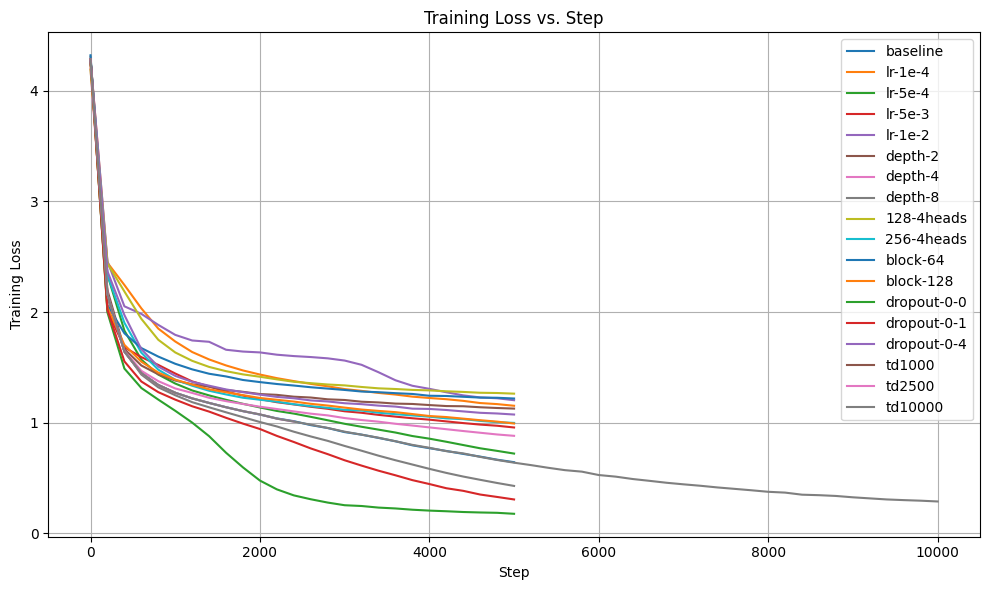

In [18]:
plot_runs(all_runs, show_train=True, show_val=False)

Show Validation Loss

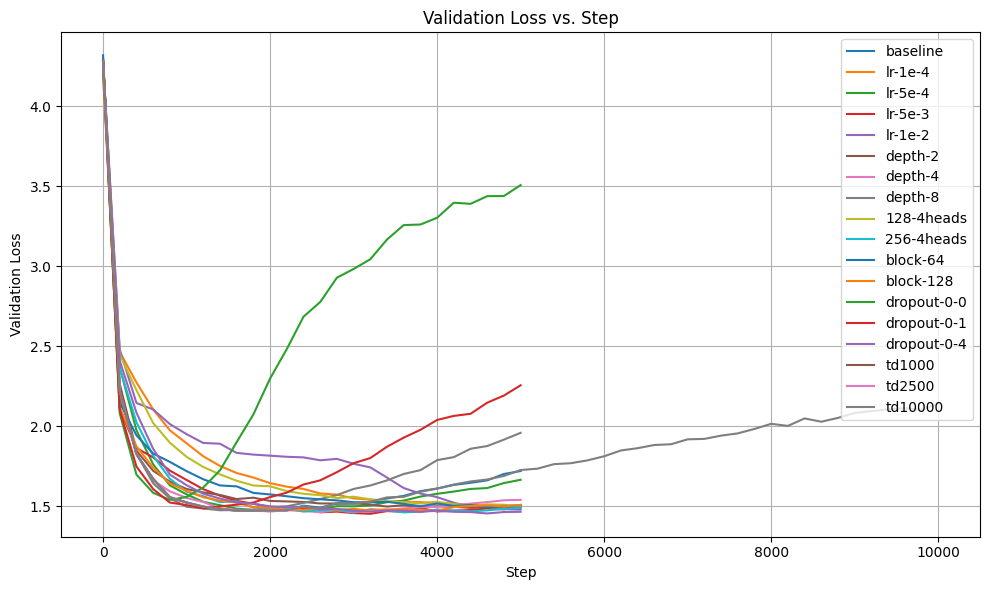

In [19]:
plot_runs(all_runs, show_train=False, show_val=True)

How To select specific runs

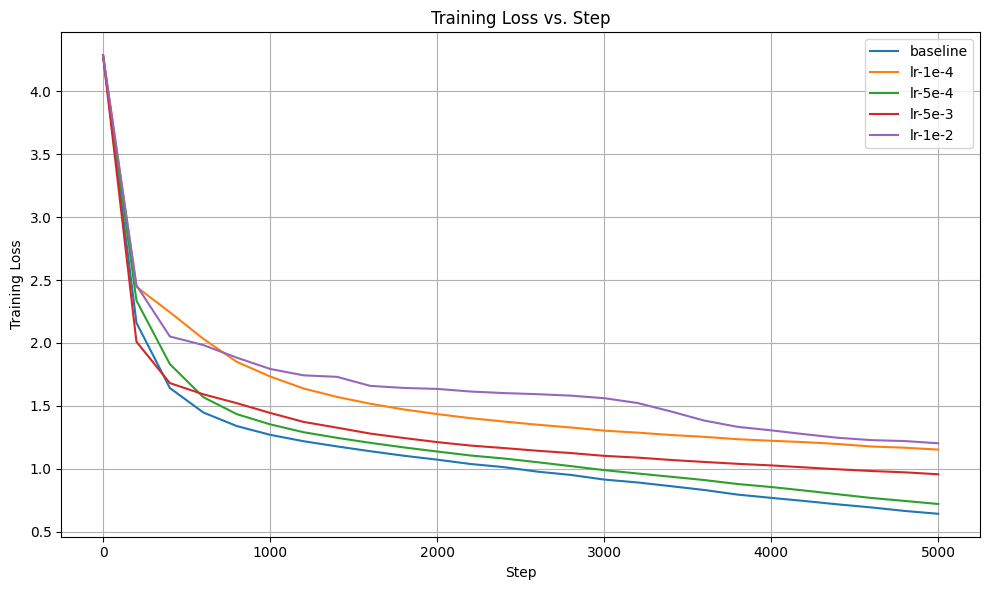

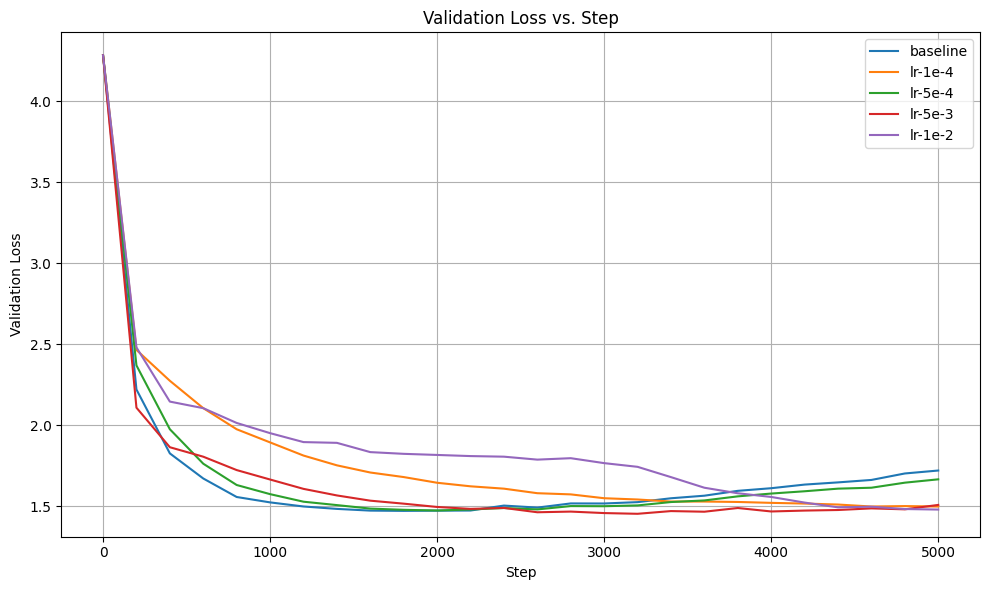

In [33]:
plot_runs(all_runs,  selected_runs=["baseline", "lr-1e-4", "lr-5e-4", "lr-5e-3", "lr-1e-2"])

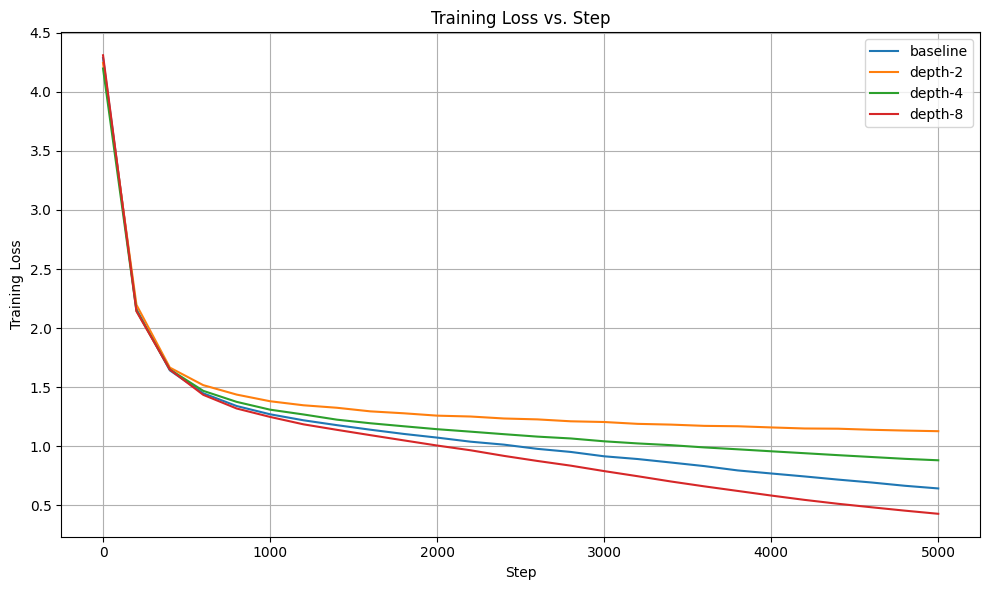

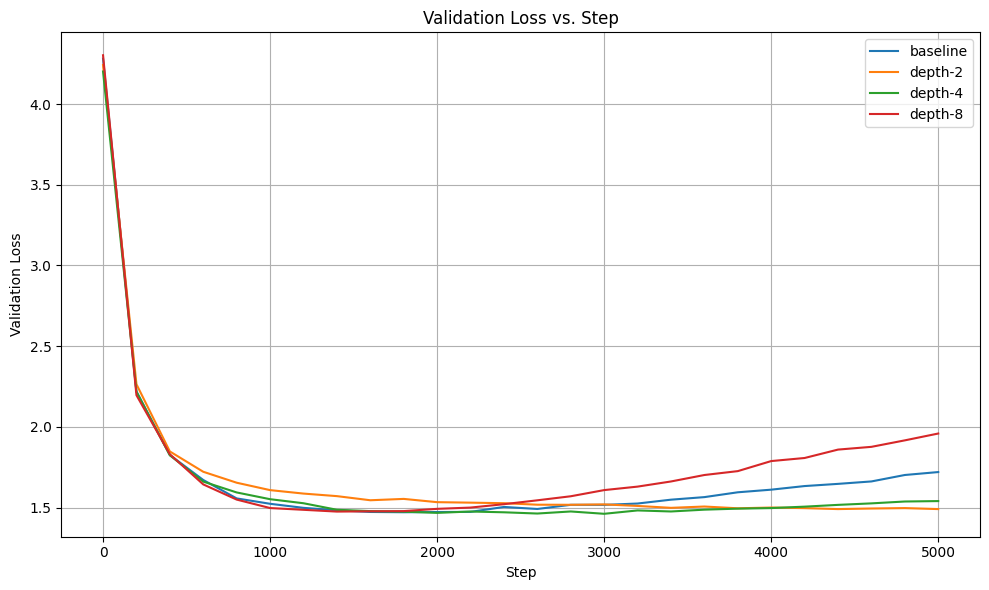

In [34]:
plot_runs(all_runs, selected_runs=["baseline", "depth-2", "depth-4", "depth-8"])

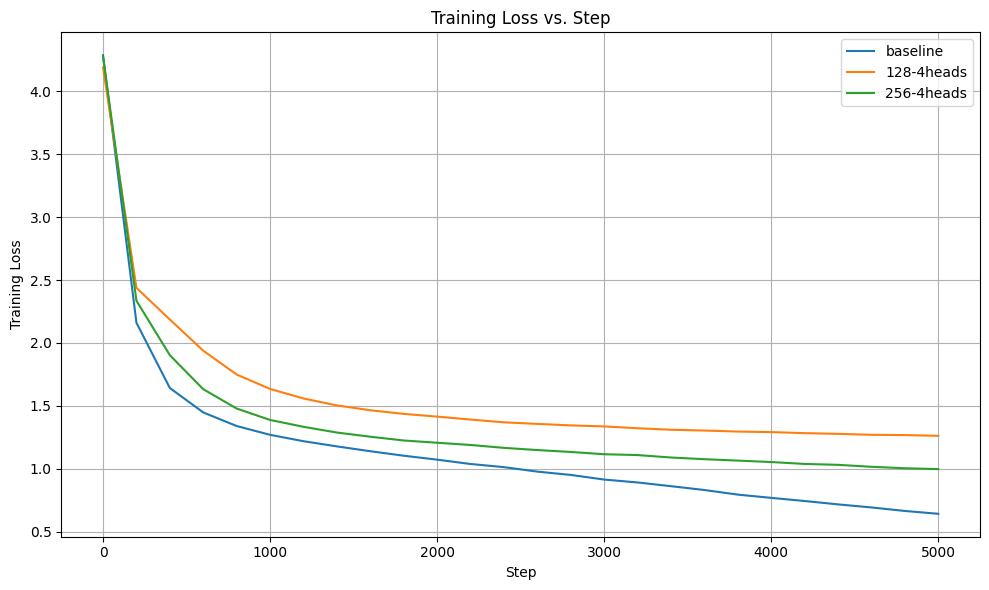

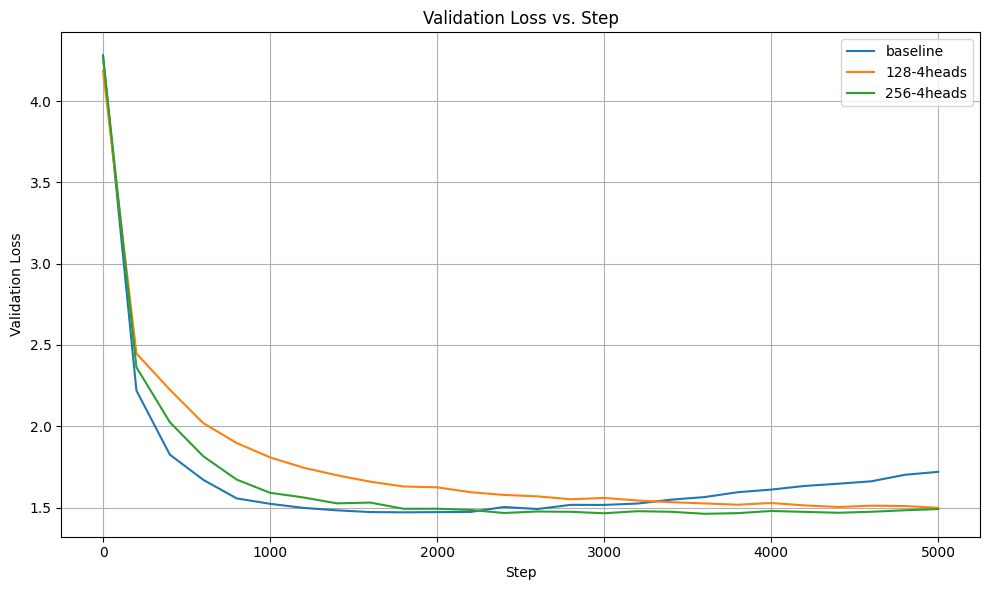

In [35]:
plot_runs(all_runs, selected_runs=["baseline", "128-4heads", "256-4heads"])

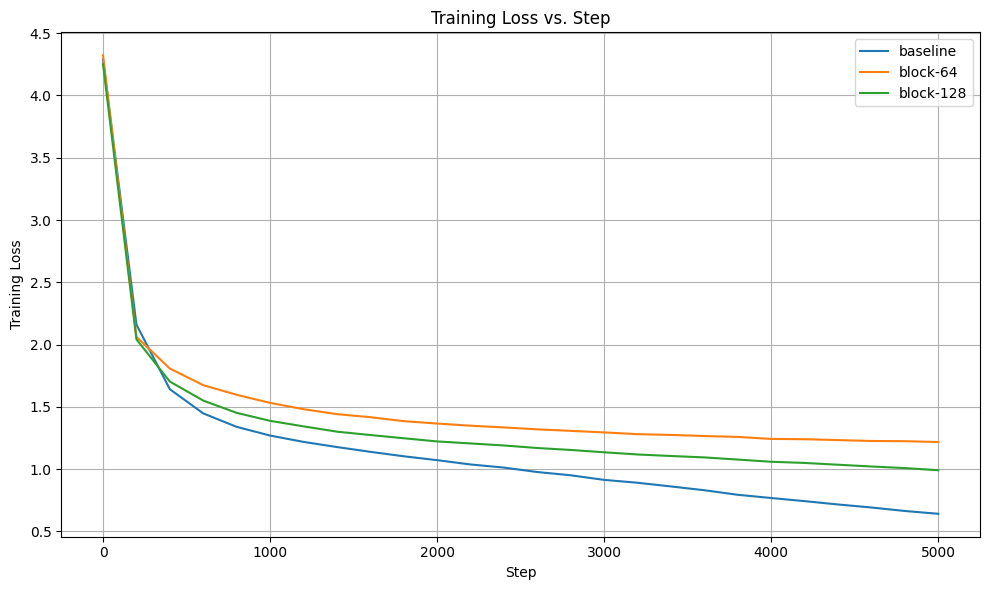

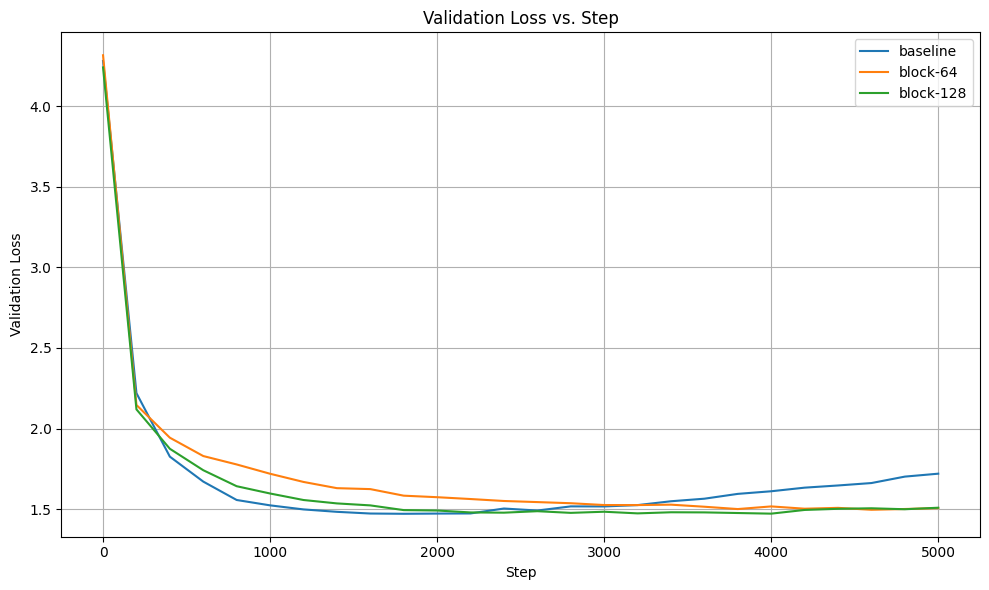

In [36]:
plot_runs(all_runs, selected_runs=["baseline", "block-64", "block-128"])

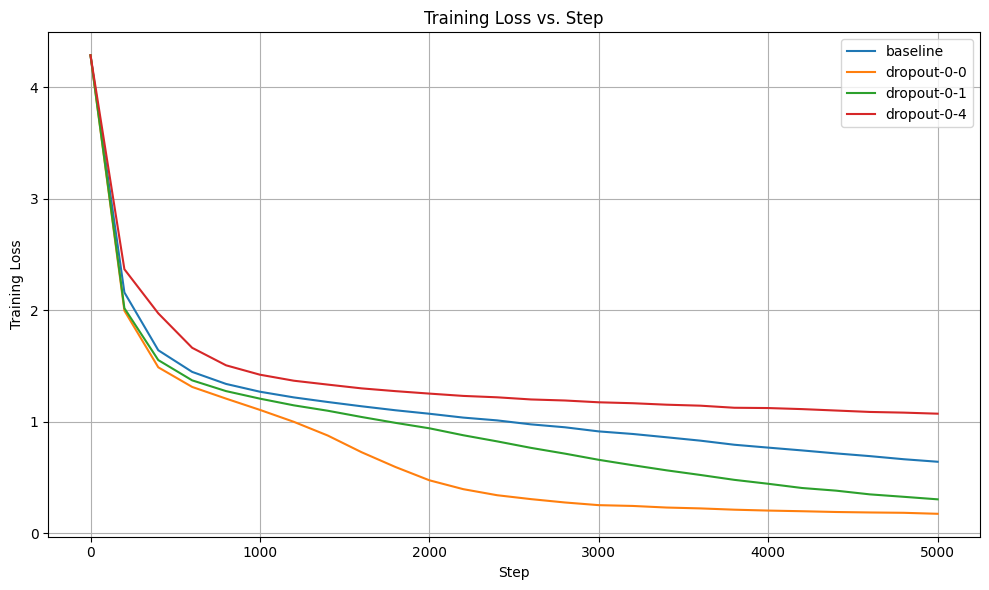

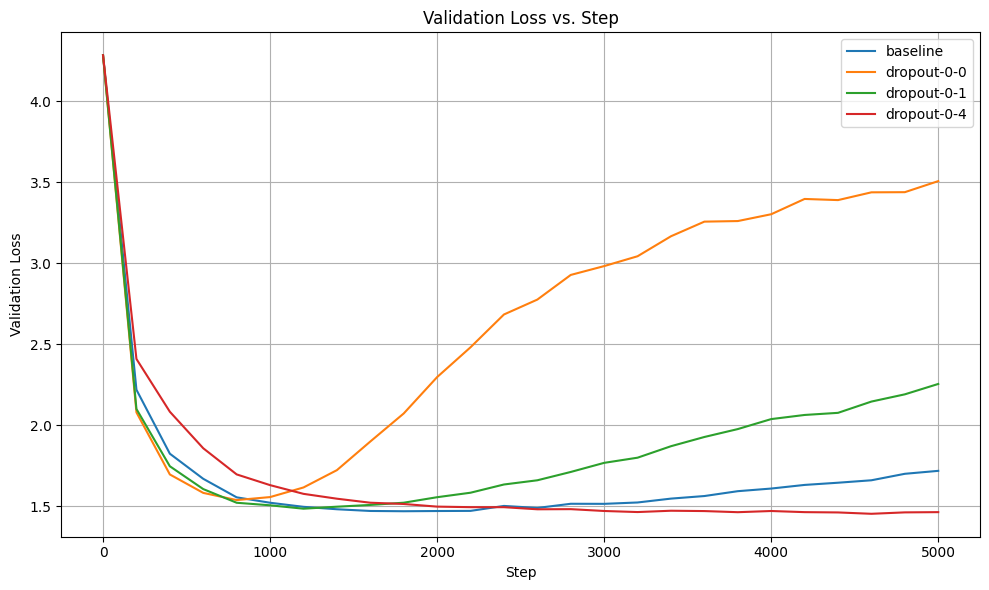

In [37]:
plot_runs(all_runs, selected_runs=["baseline", "dropout-0-0", "dropout-0-1", "dropout-0-4"])

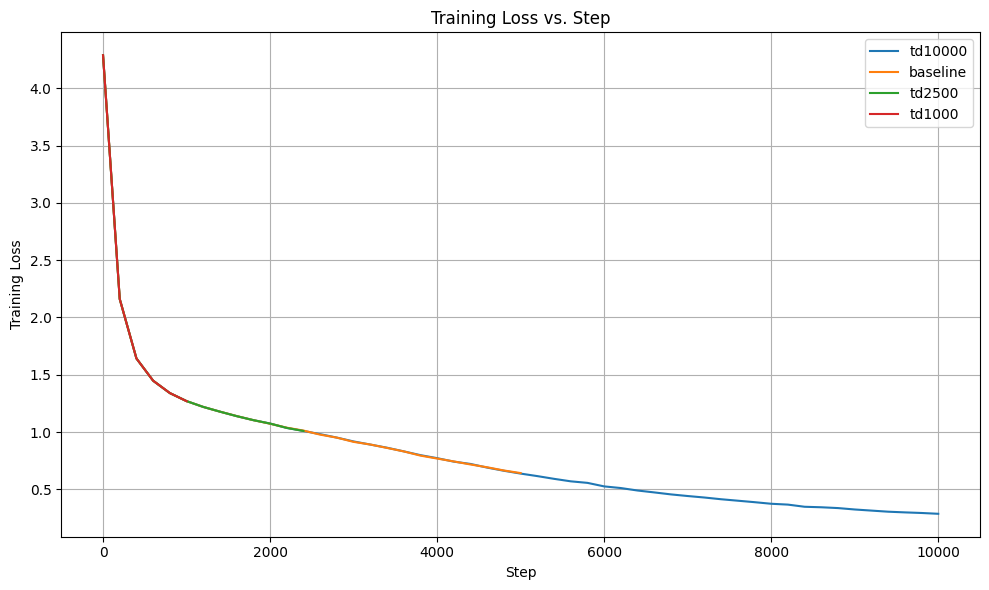

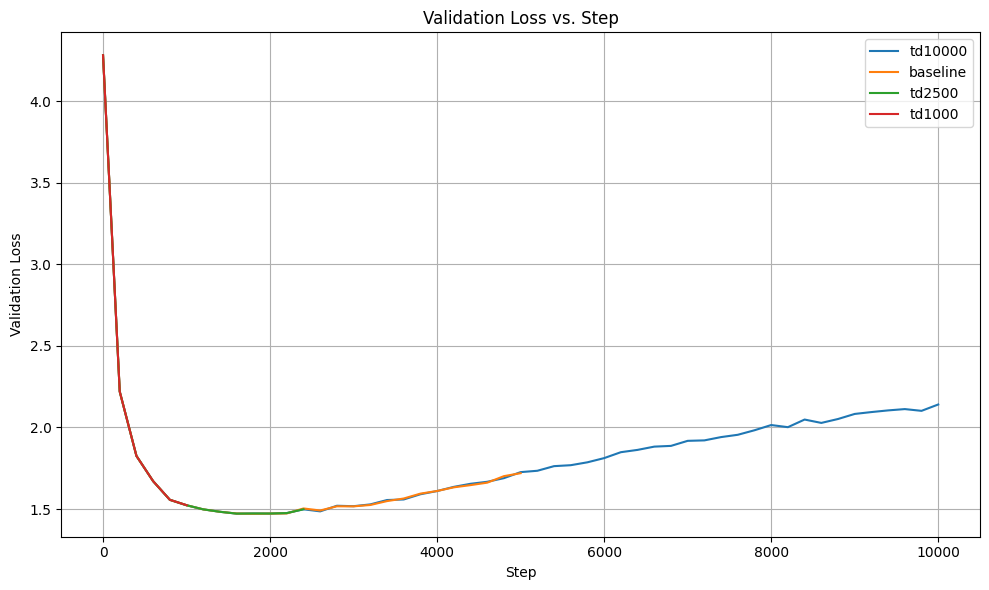

In [38]:
plot_runs(all_runs, selected_runs=["td10000", "baseline", "td2500", "td1000"])

tokens per iteration will be: 16,384
found vocab_size = 2000 (inside data\shakespeare_bpe\meta.pkl)
Initializing a new model from scratch
number of parameters: 11.39M
num decayed parameter tensors: 26, with 11,483,136 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 7.6131, val loss 7.6067
iter 0: loss 7.6278, time 4935.73ms, mfu -100.00%
iter 10: loss 6.7000, time 32.14ms, mfu 12.32%
iter 20: loss 6.1763, time 31.97ms, mfu 12.33%
iter 30: loss 5.7345, time 44.00ms, mfu 12.00%
iter 40: loss 5.5038, time 29.87ms, mfu 12.12%
iter 50: loss 5.2028, time 30.29ms, mfu 12.22%
iter 60: loss 5.0174, time 30.74ms, mfu 12.28%
iter 70: loss 4.7455, time 30.35ms, mfu 12.36%
iter 80: loss 4.5349, time 30.96ms, mfu 12.40%
iter 90: loss 4.5539, time 31.21ms, mfu 12.43%
iter 100: loss 4.5032, time 30.41ms, mfu 12.49%
iter 110: loss 4.3671, time 31.59ms, mfu 12.50%
iter 120: loss 4.2730, time 31.20ms, mfu 12.52%
iter 130: loss 4.1418, time 30.46ms, mfu 12.56%
iter 140: loss 4.1634, time 30.47ms, mfu 12.61%
iter 150: loss 4.0223, time 30.06ms, mfu 12.66%
iter 160: loss 4.0159, time 30.95ms, mfu 12.68%
iter 170: loss 3.9452, time 31.11ms, mfu 12.68%
iter 180: loss 3.9588, time 31.18ms, mfu 12.68%
iter 190: loss 3.9286, time 30.89ms, mfu 12.70%
step

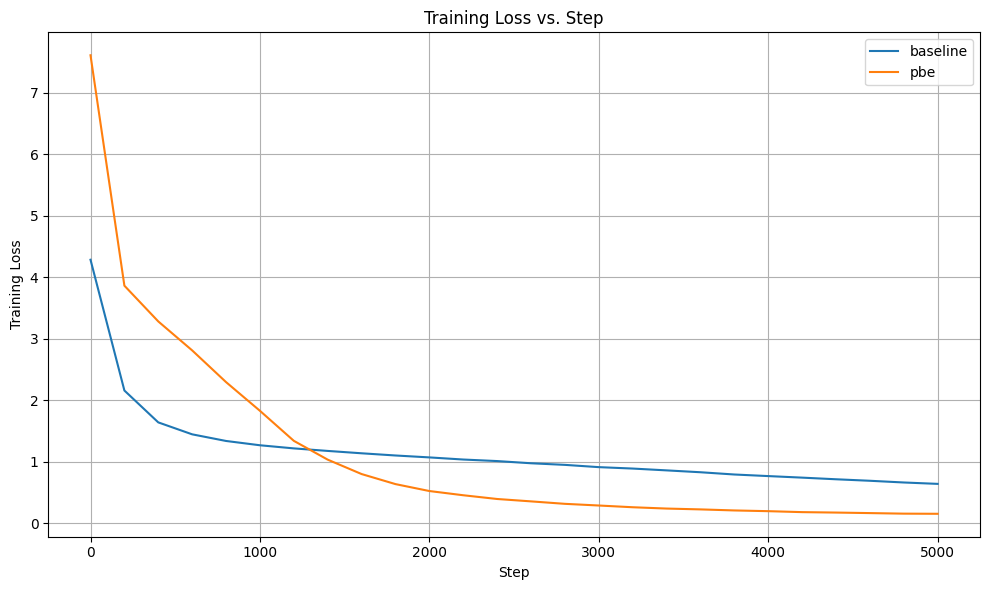

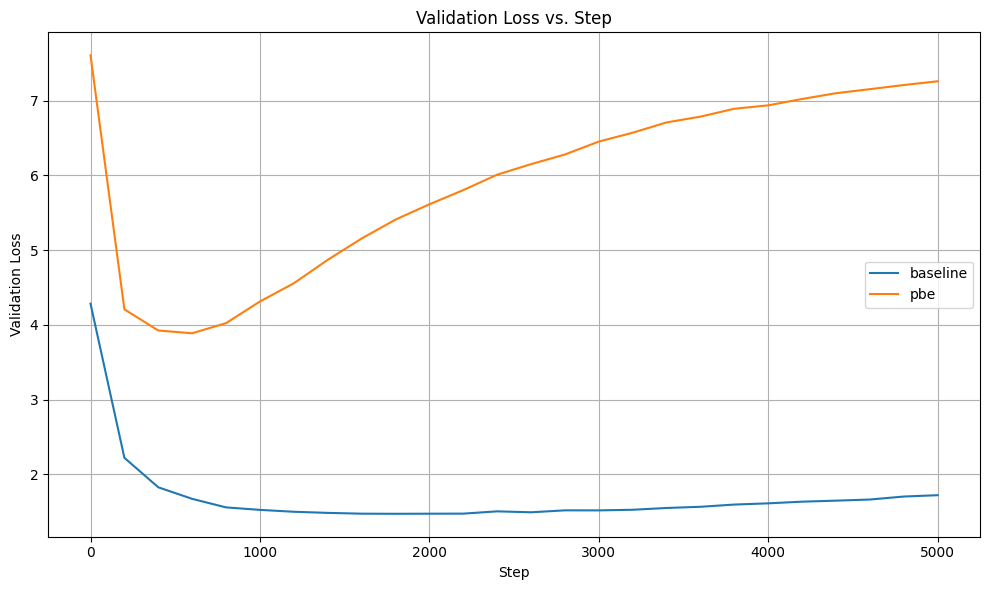

In [26]:
dataset_old = dataset
dataset = 'shakespeare_bpe'
run_name = "pbe"
wandb_run_name = run_name
out_dir = run_name
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name, tokens_char=False)

plot_runs(all_runs, selected_runs=["baseline", "pbe"])
dataset = dataset_old

In [23]:
import os
import requests

directory_path = os.path.join(os.path.abspath(""), "data", "fantasy_char")
input_file_path = os.path.join(directory_path, "input.txt")

os.makedirs(directory_path, exist_ok=True)

fantasy_urls = [
    "https://m.gutenberg.org/files/61077/61077-0.txt",
    "https://m.gutenberg.org/files/8395/8395-0.txt",
    "https://m.gutenberg.org/files/8183/8183-0.txt",
    "https://m.gutenberg.org/files/7477/7477-0.txt",
]

all_texts = []
for url in fantasy_urls:
    r = requests.get(url)
    r.raise_for_status()
    all_texts.append(r.text)

data = "\n\n".join(all_texts)

with open(input_file_path, "w", encoding="utf-8") as f:
    f.write(data)

print(f"Saved merged fantasy corpus to {input_file_path}")
print(f"Size in KB: {os.path.getsize(input_file_path) / 1024:.2f}")

Saved merged fantasy corpus to c:\Users\lunat\Documents\GitHub\foundations_NLP\final_assignment\data\fantasy_char\input.txt
Size in KB: 851.15


In [31]:
prepare_dataset(
    dataset_name="fantasy_char",
    custom_input_file = "data/fantasy_char/input.txt", 
    default_dataset=False
)

c:\Users\lunat\Documents\GitHub\foundations_NLP\final_assignment\data\fantasy_char
length of dataset in characters: 852,531
all the unique characters: 
 !"#$%'()*,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_abcdefghijklmnopqrstuvwxyz·Îéëā—‘’“”•…‰™﻿
vocab size: 98
train has 767,277 tokens
val has 85,254 tokens

Done.


{'dataset_dir': 'c:\\Users\\lunat\\Documents\\GitHub\\foundations_NLP\\final_assignment\\data\\fantasy_char',
 'input_file_path': 'c:\\Users\\lunat\\Documents\\GitHub\\foundations_NLP\\final_assignment\\data\\fantasy_char\\input.txt',
 'tokenizer_mode': True,
 'dataset_mode': False}

tokens per iteration will be: 16,384
found vocab_size = 98 (inside data\fantasy_char\meta.pkl)
Initializing a new model from scratch
number of parameters: 10.66M
num decayed parameter tensors: 26, with 10,752,768 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_9608\3679710895.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.5930, val loss 4.5953
iter 0: loss 4.6333, time 4210.46ms, mfu -100.00%
iter 10: loss 3.0993, time 30.00ms, mfu 12.43%
iter 20: loss 2.6788, time 31.29ms, mfu 12.38%
iter 30: loss 2.5205, time 30.99ms, mfu 12.35%
iter 40: loss 2.4288, time 30.88ms, mfu 12.32%
iter 50: loss 2.3939, time 30.09ms, mfu 12.33%
iter 60: loss 2.3935, time 30.62ms, mfu 12.31%
iter 70: loss 2.3869, time 31.00ms, mfu 12.29%
iter 80: loss 2.3944, time 30.91ms, mfu 12.26%
iter 90: loss 2.3578, time 29.57ms, mfu 12.30%
iter 100: loss 2.3709, time 18.00ms, mfu 13.14%
iter 110: loss 2.3815, time 28.90ms, mfu 13.12%
iter 120: loss 2.3657, time 18.31ms, mfu 13.84%
iter 130: loss 2.3475, time 31.35ms, mfu 13.65%
iter 140: loss 2.3495, time 30.68ms, mfu 13.50%
iter 150: loss 2.2767, time 30.79ms, mfu 13.36%
iter 160: loss 2.2784, time 31.56ms, mfu 13.21%
iter 170: loss 2.2257, time 31.01ms, mfu 13.09%
iter 180: loss 2.1801, time 30.21ms, mfu 13.02%
iter 190: loss 2.1313, time 18.50ms, mfu 13.73%
step

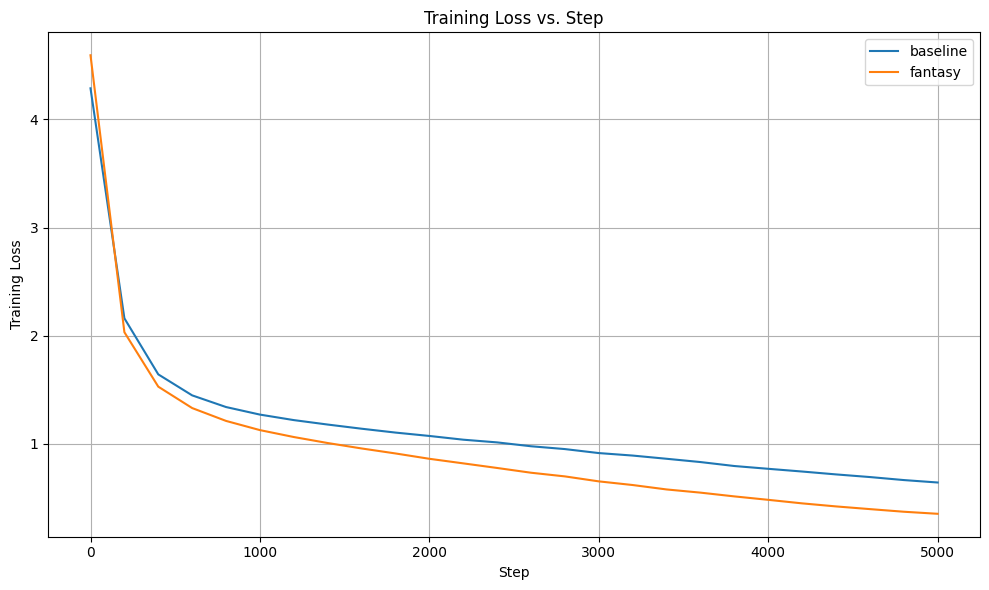

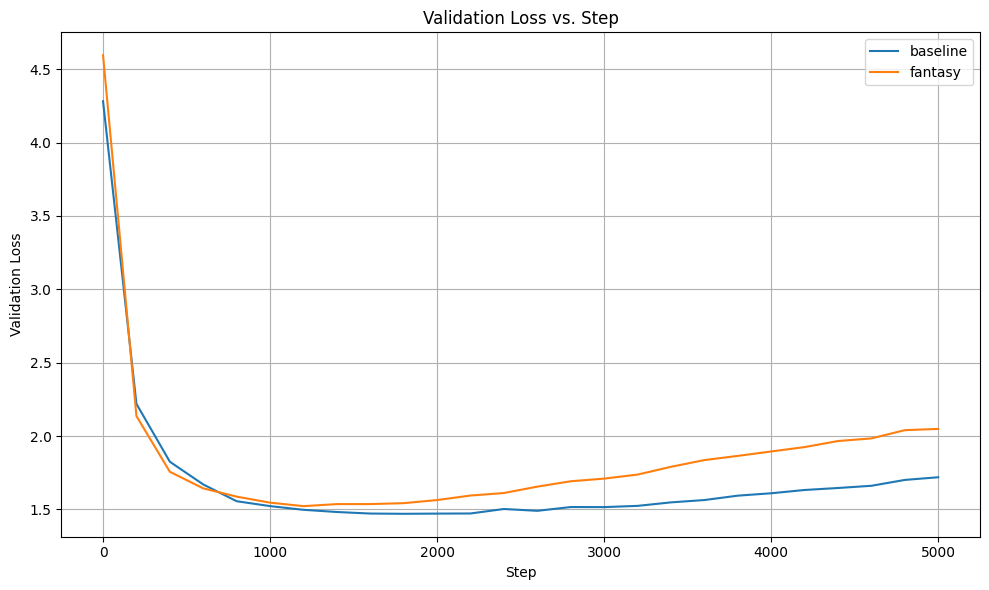

In [32]:
dataset_old = dataset
dataset = 'fantasy_char'
run_name = "fantasy"
wandb_run_name = run_name
out_dir = run_name
all_runs[run_name] = run()
all_samples[run_name] = generate_for_run(run_name=run_name)

plot_runs(all_runs, selected_runs=["baseline", "fantasy"])
dataset = dataset_old